In [1]:
from glob import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import warnings
import xarray as xr
import rasterio
import geopandas as gpd
import os
from scipy import signal
from scipy.signal import detrend
from sklearn.preprocessing import StandardScaler
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import Point
from shapely.prepared import prep 
from rasterio.features import geometry_mask
from scipy.stats import pearsonr
from scipy.stats import linregress
from scipy import stats
warnings.filterwarnings('ignore')

In [2]:

## 时间切片
def time_sel(data, yearbegin, yearend):
    data = data.sel(time=slice(f'{yearbegin}-01-01', f'{yearend}-12-31'))
    return data

## 去季节循环 + 去线性趋势
def detrend_weather(data):
    lon = data['lon']
    lat = data['lat']
    time = data['time']

    data_np = data.values.reshape((12, int(len(data) / 12), len(lat), len(lon)), order='F').transpose((1, 0, 2, 3))
    data_season = np.mean(data_np, axis=0)
    data_diff = data_np - data_season
    data_diff = data_diff.transpose((1, 0, 2, 3)).reshape((len(time), len(lat), len(lon)), order='F')

    # 这里建议用 data_diff 本身来做 mask，更安全
    data_diff = np.ma.masked_array(data_diff, mask=np.isnan(data_diff))
    data_diff = xr.DataArray(data_diff, coords=[time, lat, lon], dims=['time', 'lat', 'lon'])

    data_detrend = signal.detrend(data_diff.fillna(0), axis=0, type='linear', bp=0)
    data_detrend = xr.DataArray(data_detrend, coords=[time, lat, lon], dims=['time', 'lat', 'lon'])

    return data_detrend

In [3]:

## 读取 ERA5-Land soil moisture
ds = xr.open_dataset('/Volumes/limenghan/ERA5/soil_moisture/era5_monthly_swvl2_swvl3_1950_2024.nc')

# 坐标改名
rename_dict = {}
if 'longitude' in ds.coords:
    rename_dict['longitude'] = 'lon'
if 'latitude' in ds.coords:
    rename_dict['latitude'] = 'lat'
if 'valid_time' in ds.coords:
    rename_dict['valid_time'] = 'time'
if rename_dict:
    ds = ds.rename(rename_dict)

# 先时间切片
ds = ds.sel(time=slice('1980-01-01', '2020-12-31'))

# 如果经度是 0~360，转成 -180~180
if ds.lon.max() > 180:
    ds = ds.assign_coords(lon=((ds.lon + 180) % 360) - 180).sortby('lon')

# 先转成 float32，减少内存
ds = ds.astype('float32')

# =========================================================
# 方法1：如果原始分辨率是规则高分辨率网格，直接 coarsen 到 0.5°
# =========================================================
# 例如 ERA5-Land 常见是 0.1°，那么 5×5 平均后就是 0.5°
dlat = float(ds.lat.diff('lat').mean())
dlon = float(ds.lon.diff('lon').mean())

print('original resolution:', dlat, dlon)

lat_factor = int(round(0.5 / abs(dlat)))
lon_factor = int(round(0.5 / abs(dlon)))

ds_05 = ds.coarsen(lat=lat_factor, lon=lon_factor, boundary='trim').mean()

# =========================================================
# 如果你更想严格定义 0.5° 网格中心，也可以再 assign 一下坐标
# 一般 coarsen 后直接用也可以
# =========================================================

# 裁剪巴西区域
ds_05_bra = ds_05.sel(lon=slice(-75, -34), lat=slice(6, -40))

## 提取第2、3层
sm2 = ds_05_bra['swvl2']
sm3 = ds_05_bra['swvl3']

## 厚度加权平均，得到根区土壤湿度
thk2 = 0.21
thk3 = 0.72
smroot = (sm2 * thk2 + sm3 * thk3) / (thk2 + thk3)
smroot.name = 'smroot'
smroot.attrs['long_name'] = 'Root-zone soil moisture from ERA5-Land layer 2 and 3'
smroot.attrs['units'] = 'm3 m-3'
smroot.attrs['depth'] = '0.07-1.00 m'
smroot.attrs['resolution'] = '0.5 degree'

# 去趋势
smroot = detrend_weather(smroot)
smroot_bra=smroot
smroot_bra

original resolution: -0.25 0.25


<xarray.DataArray (time: 492, lat: 92, lon: 82)>
array([[[-5.2823439e-02, -4.8655778e-02, -1.9894857e-02, ...,
          2.4565993e-06,  2.4565993e-06,  2.4565993e-06],
        [-2.5763322e-02, -2.7303526e-02, -5.0556753e-03, ...,
          2.4565993e-06,  2.4565993e-06,  2.4565993e-06],
        [-5.6235697e-03, -9.2866868e-03,  7.5409643e-02, ...,
          2.4565993e-06,  2.4565993e-06,  2.4565993e-06],
        ...,
        [ 2.4565993e-06,  2.4565993e-06,  9.7579393e-04, ...,
          2.4565993e-06,  2.4565993e-06,  2.4565993e-06],
        [ 2.4565993e-06,  2.4565993e-06,  2.4565993e-06, ...,
          2.4565993e-06,  2.4565993e-06,  2.4565993e-06],
        [ 2.4565993e-06,  2.4565993e-06,  2.4565993e-06, ...,
          2.4565993e-06,  2.4565993e-06,  2.4565993e-06]],

       [[-3.8235877e-02, -3.8226590e-02, -3.1170802e-02, ...,
         -8.7405933e-06, -8.7405933e-06, -8.7405933e-06],
        [-2.4408042e-02, -2.8699890e-02,  3.7283972e-03, ...,
         -8.7405933e-06, -8.7405933e-06, -8.7405933e-06],
        [-8.4615834e-03, -3.1353533e-03,  6.7007467e-02, ...,
         -8.7405933e-06, -8.7405933e-06, -8.7405933e-06],
...
        [-1.2040152e-06, -1.2040152e-06, -1.2758460e-03, ...,
         -1.2040152e-06, -1.2040152e-06, -1.2040152e-06],
        [-1.2040152e-06, -1.2040152e-06, -1.2040152e-06, ...,
         -1.2040152e-06, -1.2040152e-06, -1.2040152e-06],
        [-1.2040152e-06, -1.2040152e-06, -1.2040152e-06, ...,
         -1.2040152e-06, -1.2040152e-06, -1.2040152e-06]],

       [[-2.4386868e-03, -1.4103893e-02,  1.0852376e-02, ...,
          1.7110054e-06,  1.7110054e-06,  1.7110054e-06],
        [-4.6318401e-02,  2.0710785e-02,  2.4517652e-02, ...,
          1.7110054e-06,  1.7110054e-06,  1.7110054e-06],
        [-6.5433264e-02,  1.3740960e-02,  1.7148919e-02, ...,
          1.7110054e-06,  1.7110054e-06,  1.7110054e-06],
        ...,
        [ 1.7110054e-06,  1.7110054e-06, -1.4503738e-03, ...,
          1.7110054e-06,  1.7110054e-06,  1.7110054e-06],
        [ 1.7110054e-06,  1.7110054e-06,  1.7110054e-06, ...,
          1.7110054e-06,  1.7110054e-06,  1.7110054e-06],
        [ 1.7110054e-06,  1.7110054e-06,  1.7110054e-06, ...,
          1.7110054e-06,  1.7110054e-06,  1.7110054e-06]]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1980-01-01 1980-02-01 ... 2020-12-01
  * lat      (lat) float64 5.875 5.375 4.875 4.375 ... -38.62 -39.12 -39.62
  * lon      (lon) float64 -74.88 -74.38 -73.88 -73.38 ... -35.38 -34.88 -34.38

In [4]:
def trans_lon(ds):
    lon_name = 'lon'  #你的nc文件中经度的命名
    ds['longitude_adjusted'] = xr.where(
        ds[lon_name] > 180,
        ds[lon_name] - 360,
        ds[lon_name])
    ds = (
        ds
        .swap_dims({lon_name: 'longitude_adjusted'})
        .sel(**{'longitude_adjusted': sorted(ds.longitude_adjusted)})
        .drop(lon_name))
    ds = ds.rename({'longitude_adjusted': lon_name})
    return ds

In [5]:
#flux
# 指定包含所有文件的文件夹路径
folder_path = '/Volumes/limenghan/气象要素/flux/'
# 使用通配符 '*' 来匹配文件夹中所有的 nc 文件
files = folder_path + '*.nc'
# 使用 open_mfdataset 函数来打开所有匹配的文件，并将它们合并成一个 Dataset
flux= xr.open_mfdataset(files, combine='nested', concat_dim='time')
flux= flux.rename({'longitude': 'lon'})
flux= flux.rename({'latitude': 'lat'})
# 使用 coarsen 进行降采样
if len(flux.lon)>180:
    # 定义经度和纬度的降采样因子
    lon_factor, lat_factor = int(len(flux.lat)/360), int(len(flux.lon)/720)  # 对应的降采样因子
    # 使用 coarsen 方法进行降采样
    flux=flux.coarsen(lon=lon_factor, lat=lat_factor, boundary="trim").mean()
msdwswrf=flux['msdwswrf']
##时间切片
msdwswrf=time_sel(msdwswrf,1980,2020)
msdwswrf=detrend_weather(msdwswrf)
if msdwswrf.lon.max()>180:
    msdwswrf=trans_lon(msdwswrf)
msdwswrf_bra=msdwswrf.sel(lon=slice(-75,-34), lat=slice(6,-40))

In [6]:
#evap
# 指定包含所有文件的文件夹路径
folder_path = '/Volumes/limenghan/气象要素/evap/'
# 使用通配符 '*' 来匹配文件夹中所有的 nc 文件
files = folder_path + '*.nc'
# 使用 open_mfdataset 函数来打开所有匹配的文件，并将它们合并成一个 Dataset
evap= xr.open_mfdataset(files, combine='nested', concat_dim='time')
evap= evap.rename({'longitude': 'lon'})
evap= evap.rename({'latitude': 'lat'})
# 使用 coarsen 进行降采样
if len(evap.lon)>180:
    # 定义经度和纬度的降采样因子
    lon_factor, lat_factor = int(len(evap.lat)/360), int(len(evap.lon)/720)  # 对应的降采样因子
    # 使用 coarsen 方法进行降采样
    evap= evap.coarsen(lon=lon_factor, lat=lat_factor, boundary="trim").mean()
evap=evap['e']
##时间切片
evap=time_sel(evap,1980,2020)
evap=detrend_weather(evap)
evap=time_sel(evap,1980,2020)
if evap.lon.max()>180:
    evap=trans_lon(evap)
evap_bra=evap.sel(lon=slice(-75,-34), lat=slice(6,-40))

In [7]:
##dtr
dtr=xr.open_dataset('/Volumes/limenghan/气象要素/cru_ts4.07.1901.2022.dtr.dat.nc')
dtr=dtr['dtr']
dtr=time_sel(dtr,1980,2020)
dtr=detrend_weather(dtr)
dtr=time_sel(dtr,1980,2020)
if dtr.lon.max()>180:
    dtr=trans_lon(dtr)
dtr_bra=dtr.sel(lon=slice(-75,-34), lat=slice(-40,6))

In [8]:
##cloud
cld=xr.open_dataset('/Volumes/limenghan/气象要素/cru_ts4.04.1901.2019.cld.dat.nc')
cld=cld['cld']                                                                                                                                                                                       
cld=time_sel(cld,1980,2020)
cld=detrend_weather(cld)
cld=time_sel(cld,1980,2020)
if cld.lon.max()>180:
    cld=trans_lon(cld)
cld_bra=cld.sel(lon=slice(-75,-34), lat=slice(-40,6))

In [9]:
##wet
wet=xr.open_dataset('/Volumes/limenghan/气象要素/cru_ts4.07.1901.2022.wet.dat.nc')
wet=wet['wet']
wet=time_sel(wet,1980,2020)
wet=detrend_weather(wet)
wet=time_sel(wet,1980,2020)
if wet.lon.max()>180:
    wet=trans_lon(wet)
wet_bra=wet.sel(lon=slice(-75,-34), lat=slice(-40,6))

In [10]:
##tmx
tmx=xr.open_dataset('/Volumes/limenghan/气象要素/cru_ts4.07.1901.2022.tmx.dat.nc')
tmx=tmx['tmx']
tmx=time_sel(tmx,1980,2020)
tmx=detrend_weather(tmx)
tmx=time_sel(tmx,1980,2020)
if tmx.lon.max()>180:
    tmx=trans_lon(tmx)
tmx_bra=tmx.sel(lon=slice(-75,-34), lat=slice(-40,6))

In [11]:
##tmp
tmp=xr.open_dataset('/Volumes/limenghan/气象要素/cru_ts4.07.1901.2022.tmp.dat.nc')
tmp=tmp['tmp']
tmp=time_sel(tmp,1980,2020)
tmp=detrend_weather(tmp)
tmp=time_sel(tmp,1980,2020)
if tmp.lon.max()>180:
    tmp=trans_lon(tmp)
tmp_bra=tmp.sel(lon=slice(-75,-34), lat=slice(-40,6))

In [12]:
##pre
pre=xr.open_dataset('/Volumes/limenghan/气象要素/cru_ts4.04.1901.2019.pre.dat.nc')
pre=pre['pre']
pre=time_sel(pre,1980,2020)
pre=detrend_weather(pre)
pre=time_sel(pre,1980,2020)
if pre.lon.max()>180:
    pre=trans_lon(pre)
pre_bra=pre.sel(lon=slice(-75,-34), lat=slice(-40,6))

In [13]:
##vap
vap=xr.open_dataset('/Volumes/limenghan/气象要素/cru_ts4.07.1901.2022.vap.dat.nc')
vap=vap['vap']
vap=time_sel(vap,1980,2020)
vap=detrend_weather(vap)
vap=time_sel(vap,1980,2020)
if vap.lon.max()>180:
    vap=trans_lon(vap)
vap_bra=vap.sel(lon=slice(-75,-34), lat=slice(-34,6))
# 将值为 0 的点 mask 掉，设为 NaN
tmp_bra = tmp_bra.where(tmp_bra!= 0, np.nan)
vap_bra = vap_bra.where(vap_bra!= 0, np.nan)
##vpd
e0 = 6.108 *np.exp(17.27 * tmp / (tmp + 237.3))
vpd=e0-vap
vpd_bra=vpd.sel(lon=slice(-75,-34), lat=slice(-40,6))

In [14]:
variable_list=['dtr','cld','wet','tmp','tmx','pre','vpd','evap','msdwswrf','smroot','vap']
for i in variable_list:
    locals()[f'{i}_bra_sort']=locals()[f'{i}_bra'].sortby(['lat', 'lon'])

In [15]:
##全球地图
def capitalize_words(s):
    # 检查元素是否是字符串，如果是，就进行首字母大写操作，如果不是，返回原始值
    if isinstance(s, str):
        return ' '.join(word.capitalize() for word in s.split())
    else:
        return s
world = gpd.read_file("/Users/limenghan/Desktop/地图/world_shp/世界国家.shp")
world = world.set_crs(epsg=4326)
world.rename(columns={'NAME': 'loc'}, inplace=True)
world["loc"]= np.vectorize(capitalize_words, otypes=[object])(world["loc"])

Brazil = gpd.read_file("/Users/limenghan/Desktop/地图/次国家/gadm41_BRA_shp/gadm41_BRA_1.shp")
Brazil.rename(columns={'NAME_1': 'loc'}, inplace=True)
BRA_shp = gpd.read_file("/Volumes/limenghan/地图/gadm41_BRA_shp/gadm41_BRA_0.shp")
BRA_shp.rename(columns={'NAME_1': 'loc'}, inplace=True)

In [16]:
import xarray as xr
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# ============================
# 1️⃣ 读取海冰数据
# ============================
sic_file = "/Volumes/limenghan/气候变率/HadISST_ice.nc"
print("Loading SIC dataset...")
sic = xr.open_dataset(sic_file)['sic']

# 坐标标准化
def standardize_coords(da):
    coords = list(da.coords)
    if 'latitude' not in coords:
        lat_name = next(k for k in coords if 'lat' in k)
        da = da.rename({lat_name: 'latitude'})
    if 'longitude' not in coords:
        lon_name = next(k for k in coords if 'lon' in k)
        da = da.rename({lon_name: 'longitude'})
    return da

sic = standardize_coords(sic)

# 重采样到月起点
sic_ms = sic.resample(time='MS').mean(dim='time', skipna=True)
time_idx = pd.to_datetime(sic_ms.time.values)

# ============================
# 2️⃣ 区域选择与加权平均
# ============================
def select_region(da, lat1, lat2, lon1, lon2):
    # 纬度 slice
    if da.latitude[0] > da.latitude[-1]:
        lat_slice = slice(max(lat1, lat2), min(lat1, lat2))
    else:
        lat_slice = slice(min(lat1, lat2), max(lat1, lat2))
    
    # 经度 wrap-around
    if lon1 <= lon2:
        da_sel = da.sel(latitude=lat_slice, longitude=slice(lon1, lon2))
    else:
        da1 = da.sel(latitude=lat_slice, longitude=slice(lon1, da.longitude.max().item()))
        da2 = da.sel(latitude=lat_slice, longitude=slice(da.longitude.min().item(), lon2))
        da_sel = xr.concat([da1, da2], dim='longitude').sortby('longitude')
    
    if da_sel.sizes['latitude'] == 0 or da_sel.sizes['longitude'] == 0:
        print(f"Warning: empty selection lat({lat1},{lat2}) lon({lon1},{lon2})")
    return da_sel

def weighted_mean(da):
    weights = np.cos(np.deg2rad(da.latitude))
    return (da * weights).mean(dim=['latitude', 'longitude'], skipna=True)

# ============================
# 3️⃣ 计算海冰指数
# ============================
ice_df = pd.DataFrame(index=time_idx)

# 北极/南极总海冰
ice_df['NH_ice'] = weighted_mean(select_region(sic_ms, 50, 90, -180, 180))
ice_df['SH_ice'] = weighted_mean(select_region(sic_ms, -90, -50, -180, 180))

# 南极海冰偶极: Weddell - Ross
weddell = select_region(sic_ms, -70, -50, -70, 20)
ross    = select_region(sic_ms, -70, -50, 160, -130)
ice_df['Antarctic_Dipole'] = weighted_mean(weddell) - weighted_mean(ross)

# 南极半岛–Amundsen–Ross
peninsula = select_region(sic_ms, -70, -60, -90, -50)
amundsen_ross = select_region(sic_ms, -75, -65, 160, -130)
ice_df['Peninsula_Amundsen_Ross'] = weighted_mean(peninsula) + weighted_mean(amundsen_ross)

# 巴伦支-喀拉
barents = select_region(sic_ms, 70, 80, 20, 60)
kara    = select_region(sic_ms, 70, 80, 60, 90)
ice_df['Barents_Kara'] = weighted_mean(barents) + weighted_mean(kara)

# 楚科奇-白令-拉普捷夫
chukchi = select_region(sic_ms, 65, 75, 170, -160)
bering  = select_region(sic_ms, 60, 70, -170, -150)
laptev  = select_region(sic_ms, 70, 80, 100, 140)
ice_df['Chukchi_Bering_Laptev'] = weighted_mean(chukchi) + weighted_mean(bering) + weighted_mean(laptev)

# ============================
# 4️⃣ 去季节、去趋势、标准化
# ============================
def remove_monthly_mean(series):
    return series - series.groupby(series.index.month).transform('mean')

def detrend_series(y):
    y = np.asarray(y, dtype=float)
    isnan = np.isnan(y)
    if isnan.all(): return y
    t = np.arange(len(y))[~isnan].reshape(-1, 1)
    y_nonan = y[~isnan]
    if len(y_nonan) < 3: return y
    lr = LinearRegression().fit(t, y_nonan)
    y_out = np.full_like(y, np.nan, dtype=float)
    y_out[~isnan] = y_nonan - lr.predict(t)
    return y_out

def zscore(x):
    x = np.asarray(x, dtype=float)
    mn, sd = np.nanmean(x), np.nanstd(x)
    if sd == 0 or np.isnan(sd): return x - mn
    return (x - mn) / sd

for col in ice_df.columns:
    s = pd.Series(ice_df[col].values, index=time_idx)
    s = remove_monthly_mean(s)
    s = detrend_series(s.values)
    s = zscore(s)
    ice_df[col] = s

# 双重索引
ice_df['year'] = ice_df.index.year
ice_df['month'] = ice_df.index.month
df_out = ice_df.set_index(['year', 'month']).sort_index()

# ============================
# 5️⃣ 读取气候数据 & 去趋势 & 去季节
# ============================
climate_series = pd.read_excel('/Volumes/limenghan/气候变率/ClimateSeries.xlsx', index_col=[0,1])
climate_series = climate_series['1976':'2017']

def detrend(column):
    valid = column.dropna()
    if len(valid) < 2:
        return column
    X = np.arange(len(valid)).reshape(-1, 1)
    y = valid.values.reshape(-1, 1)
    model = LinearRegression()
    model.fit(X, y)
    trend = model.predict(X)
    deseasoned = y - trend
    result = pd.Series(np.nan, index=column.index)
    result[valid.index] = deseasoned.flatten()
    return result

def remove_seasonality(column):
    valid = column.dropna()
    if len(valid) < 2: return column
    month_index = valid.index.get_level_values('month')
    month_dummies = pd.get_dummies(month_index)
    X = month_dummies.values
    y = valid.values.reshape(-1, 1)
    model = LinearRegression()
    model.fit(X, y)
    seasonal = model.predict(X)
    deseasoned = y - seasonal
    result = pd.Series(np.nan, index=column.index)
    result[valid.index] = deseasoned.flatten()
    return result

climate_series_detrended = climate_series.apply(detrend)
climate_series_detrended = climate_series_detrended.groupby(level='month').apply(lambda df: df.apply(remove_seasonality))
climate_series_detrended = climate_series_detrended.reset_index(level=0, drop=True)
climate_series_detrended = climate_series_detrended.sort_values(by=['year', 'month'])

# ============================
# 6️⃣ 去除 Nino3.4 与 IOB 信号
# ============================
def orth_multi(A, b):
    """将b在多列A上正交化，返回去除A投影后的b"""
    A = np.asarray(A)
    b = np.asarray(b)
    if A.ndim == 1:
        A = A.reshape(-1, 1)
    valid = ~np.isnan(A).any(axis=1) & ~np.isnan(b)
    if valid.sum() < 3:
        return b
    A_valid = A[valid]
    b_valid = b[valid]
    coef = np.linalg.lstsq(A_valid, b_valid, rcond=None)[0]
    b_resid = b_valid - A_valid @ coef
    b_out = np.full_like(b, np.nan, dtype=float)
    b_out[valid] = b_resid
    return b_out

def remove_signals(df, signals=['Nino34', 'IOB']):
    """从 df 中去除指定气候信号的线性投影"""
    existing_signals = [s for s in signals if s in df.columns]
    if not existing_signals:
        print("⚠️ 未找到任何指定信号列，跳过去信号。")
        return df

    df_out = df.copy()
    A_all = df[existing_signals].dropna(how='any')

    for col in df.columns:
        if col in existing_signals:
            continue
        common_index = A_all.index.intersection(df[col].dropna().index)
        if len(common_index) == 0:
            continue
        A = df.loc[common_index, existing_signals].values
        b = df.loc[common_index, col].values
        df_out.loc[common_index, col] = orth_multi(A, b)
    return df_out

# 对年份进行筛选
start_year = climate_series_detrended.index.get_level_values('year').min()
end_year   = climate_series_detrended.index.get_level_values('year').max()
df_overlap = df_out.loc[
    (df_out.index.get_level_values('year') >= start_year) &
    (df_out.index.get_level_values('year') <= end_year)
]

# 合并 Nino34 与 IOB
df_plus_signals = pd.concat([df_overlap, climate_series_detrended[['Nino34', 'IOB']]], axis=1)

# 去除 Nino34 与 IOB 信号
df_processed = remove_signals(df_plus_signals, signals=['Nino34', 'IOB'])
df_processed = df_processed.drop(columns=['Nino34', 'IOB'], errors='ignore')

# ============================
# ✅ 最终结果
# ============================
print("✅ 去除 Nino3.4 与 IOB 信号完成！")
print(df_processed.head())

Loading SIC dataset...
✅ 去除 Nino3.4 与 IOB 信号完成！
              NH_ice    SH_ice  Antarctic_Dipole  Peninsula_Amundsen_Ross  \
year month                                                                  
1976 1      0.762276  0.144336          0.333336                 1.059719   
     2      0.697589  0.634514          0.577264                 1.110092   
     3      0.724929  1.666558          0.125437                 3.199734   
     4      0.836091 -1.232395         -3.027264                 1.401437   
     5      0.602295 -0.041239         -3.106786                 2.810050   

            Barents_Kara  Chukchi_Bering_Laptev  
year month                                       
1976 1          0.552656               0.177908  
     2          0.544110               0.006236  
     3          0.177710               0.266074  
     4         -0.092563               0.385650  
     5         -0.121103               0.913614  


In [17]:
df_processed 

NH_ice    SH_ice  Antarctic_Dipole  Peninsula_Amundsen_Ross  \
year month                                                                  
1976 1      0.762276  0.144336          0.333336                 1.059719   
     2      0.697589  0.634514          0.577264                 1.110092   
     3      0.724929  1.666558          0.125437                 3.199734   
     4      0.836091 -1.232395         -3.027264                 1.401437   
     5      0.602295 -0.041239         -3.106786                 2.810050   
...              ...       ...               ...                      ...   
2017 8     -3.631066 -1.863693         -0.261473                -2.302041   
     9     -2.745818 -3.365584         -0.631235                -1.383345   
     10    -2.039539 -1.827885         -0.493314                -0.747512   
     11    -0.989590 -1.411629         -0.784336                 0.379079   
     12    -0.854153 -0.722137         -0.703247                 0.078475   

            Barents_Kara  Chukchi_Bering_Laptev  
year month                                       
1976 1          0.552656               0.177908  
     2          0.544110               0.006236  
     3          0.177710               0.266074  
     4         -0.092563               0.385650  
     5         -0.121103               0.913614  
...                  ...                    ...  
2017 8         -1.640220              -1.830949  
     9         -0.111648              -1.156263  
     10        -1.269769              -1.107737  
     11        -1.643574              -2.411400  
     12        -1.271631              -3.386258  

[504 rows x 6 columns]

In [18]:
##对不起呀对不起呀 前面算错了,先不改了
def calculate_seasonal_standardized_mean(data, start_month, end_month,start_year,end_year):
    """
    计算指定时间段（三个月或跨年的）标准化平均值。

    :param data: xarray.DataArray，包含时间维度 'time'
    :param start_month: 起始月份（1-12）
    :param end_month: 结束月份（1-12，跨年时需要小于起始月份）
    :return: 标准化的季节平均值，按年份分组
    """
    # 提取年份和月份信息
    if start_month<end_month:
        data = data.loc[(slice(start_year,end_year), [start_month, start_month+1, end_month])]
        ##三月平均（SON）
        data_averages =data.groupby('year').mean()
    elif start_month==11:
        # 提取第一个切片（前一年 11 月和 12 月）
        part1 = data.loc[(slice(start_year, end_year), [11, 12])]
        # 提取第二个切片（次年 1 月）
        part2 = data.loc[(slice(start_year + 1, end_year+1), [1])]
        # 合并两个部分
        data = pd.concat([part1, part2]).sort_index()
        data = data.unstack(level='month')  # 将月份展开为列
        data[1] = data[1].shift(-1)  # 将1月对齐到上一年
        # 删除可能引入的 NaN 行
        data = data.dropna()
        # 计算每组的平均值
        data_averages = data.mean(axis=1)
    elif start_month==12:
        # 提取第一个切片（前一年 12 月）
        part1 = data.loc[(slice(start_year -1, end_year - 1), [12])]
        # 提取第二个切片（次年 1 月）
        part2 = data.loc[(slice(start_year, end_year), [1,2])]
        # 合并两个部分
        data = pd.concat([part1, part2]).sort_index()
        data = data.unstack(level='month')  # 将月份展开为列
        data[12] = data[12].shift(1)  # 将12月对齐到下一年
        # 删除可能引入的 NaN 行
        data = data.dropna()
        # 计算每组的平均值
        data_averages = data.mean(axis=1)
    return data_averages

AD_NDJ_1_mean_std=calculate_seasonal_standardized_mean(df_processed['Antarctic_Dipole'], 11, 1,1980,2015)

AD_NDJ_1_mean_std

year
1980    0.902331
1981    0.227146
1982   -0.555757
1983    0.583062
1984    1.076604
1985    0.367574
1986   -0.266237
1987   -0.379052
1988    2.036132
1989    0.188884
1990   -0.774963
1991    1.178733
1992    0.014671
1993    0.926500
1994    0.754226
1995    0.663384
1996   -0.838768
1997    0.615508
1998   -1.852648
1999   -0.988496
2000    0.956203
2001   -1.670312
2002    2.394080
2003    1.311568
2004    0.109965
2005    0.440441
2006   -0.941604
2007    0.960035
2008    0.054332
2009    0.095550
2010   -0.902081
2011    1.719250
2012    1.243998
2013    1.382536
2014    0.292928
2015    0.464901
dtype: float64

In [19]:
season_months = {
    'DJF': [12, 1, 2],  # 冬季：12, 1, 2
    'JFM': [1, 2, 3],    # 初春：1, 2, 3
    'FMA': [2, 3, 4],    # 春季：2, 3, 4
    'MAM': [3, 4, 5],    # 春末：3, 4, 5
    'AMJ': [4, 5, 6],    # 初夏：4, 5, 6
    'MJJ': [5, 6, 7],    # 夏季：5, 6, 7
    'JJA': [6, 7, 8],    # 夏季：6, 7, 8
    'JAS': [7, 8, 9],    # 夏末：7, 8, 9
    'ASO': [8, 9, 10],   # 秋季：8, 9, 10
    'SON': [9, 10, 11],  # 秋末：9, 10, 11
    'OND': [10, 11, 12], # 深秋：10, 11, 12
    'NDJ': [11, 12, 1],  # 初冬：11, 12, 1
}

In [20]:

def calculate_seasonal_standardized_mean(data, start_month, end_month, start_year, end_year):
    """
    计算指定年份范围内某个季节（可跨年）的“季节平均”并进行“年际标准化”(z-score)，逐格点计算。

    参数
    ----
    data : xarray.DataArray
        维度至少包含 time（以及可选的 lat/lon 等空间维）
    start_month, end_month : int
        起止月份（1-12）。若 start_month > end_month 表示跨年（如 12-2）。
    start_year, end_year : int
        这里的 year 指“season_year”（季节年）。
        例如 DJF(12-2) 中，2015 DJF 指 2014-12 + 2015-01/02，因此 season_year=2015。

    返回
    ----
    standardized : xarray.DataArray
        维度包含 season_year（以及 lat/lon 等），值为季节平均后的标准化结果
    seasonal_mean : xarray.DataArray
        季节平均（未标准化），方便你检验
    """
    # 1) 确保 time 是 datetime64
    if not np.issubdtype(data.time.dtype, np.datetime64):
        data = data.assign_coords(time=pd.to_datetime(data.time.values))

    month = data.time.dt.month
    year  = data.time.dt.year

    # 2) 生成目标月份列表
    if start_month <= end_month:
        months = list(range(start_month, end_month + 1))
        # 不跨年：season_year 就是自然年
        season_year = year
    else:
        # 跨年：例如 12-2 或 11-1 或 10-2 等
        months = list(range(start_month, 13)) + list(range(1, end_month + 1))
        # 跨年季节：把 start_month..12 这些月份归到下一年（season_year = year+1）
        season_year = xr.where(month >= start_month, year + 1, year)

    # 3) 只保留目标季节月份 & season_year 在 [start_year, end_year]
    mask = month.isin(months) & (season_year >= start_year) & (season_year <= end_year)
    da_season = data.where(mask, drop=True)
    
    # 4) 按 season_year 做季节平均
    season_year_coord = xr.DataArray(
        season_year.where(mask, drop=True).values,
        coords={"time": da_season.time},
        dims="time",
        name="season_year"
    )
    seasonal_mean = da_season.groupby(season_year_coord).mean("time")
    seasonal_mean = seasonal_mean.rename({"group": "season_year"}) if "group" in seasonal_mean.dims else seasonal_mean
    seasonal_mean = seasonal_mean.assign_coords(season_year=sorted(np.unique(season_year_coord.values)))

    # 5) 年际标准化（逐格点）
    clim_mean = seasonal_mean.mean("season_year")
    clim_std  = seasonal_mean.std("season_year")

    standardized = (seasonal_mean - clim_mean) / clim_std

    return standardized


In [21]:
msdwswrf_JFM=calculate_seasonal_standardized_mean(msdwswrf_bra, 1, 3, 1981, 2016)
pre_JFM=calculate_seasonal_standardized_mean(pre_bra, 1, 3, 1981, 2016)
smroot_JFM=calculate_seasonal_standardized_mean(smroot_bra, 1, 3, 1981, 2016)

msdwswrf_AMJ=calculate_seasonal_standardized_mean(msdwswrf_bra, 4,6, 1981, 2016)
dtr_AMJ=calculate_seasonal_standardized_mean(dtr_bra, 4,6, 1981, 2016)
smroot_AMJ=calculate_seasonal_standardized_mean(smroot_bra, 4,6, 1981, 2016)

In [22]:
nino34=df_plus_signals['Nino34']
iob=df_plus_signals['IOB']

In [23]:
def series_to_season_year_da(s, start_month, end_month, start_year, end_year, name=None):
    """
    s: pandas.Series, MultiIndex = (year, month), values = 指数
    返回：xarray.DataArray，dim='season_year'，每个 season_year 一个季节平均值
    """
    if not isinstance(s.index, pd.MultiIndex) or s.index.nlevels != 2:
        raise ValueError("指数必须是 MultiIndex(year, month) 的 pandas.Series")

    # 取出 year/month
    years  = s.index.get_level_values(0).astype(int)
    months = s.index.get_level_values(1).astype(int)

    # 生成 time 坐标（每月1号）
    time = pd.to_datetime({"year": years, "month": months, "day": 1})
    da = xr.DataArray(s.values.astype(float), coords={"time": time}, dims="time", name=(name or s.name or "index"))

    m = da.time.dt.month
    y = da.time.dt.year

    # 目标月份 + season_year 定义
    if start_month <= end_month:
        months_sel = list(range(start_month, end_month + 1))
        season_year = y
    else:
        # 跨年季节：例如 12-2, 11-1, 10-2 等
        months_sel = list(range(start_month, 13)) + list(range(1, end_month + 1))
        season_year = xr.where(m >= start_month, y + 1, y)

    # 筛选月份 + season_year 范围
    mask = m.isin(months_sel) & (season_year >= start_year) & (season_year <= end_year)
    da_season = da.where(mask, drop=True)

    season_year_coord = xr.DataArray(
        season_year.where(mask, drop=True).values,
        coords={"time": da_season.time},
        dims="time",
        name="season_year"
    )

    # 按 season_year 做季节平均
    out = da_season.groupby(season_year_coord).mean("time")
    out = out.rename({"group": "season_year"}) if "group" in out.dims else out
    out = out.assign_coords(season_year=np.unique(season_year_coord.values))

    return out

In [24]:
iob_JFM = series_to_season_year_da(iob, 1, 3, 1981, 2016, name="IOB")
nino_JFM = series_to_season_year_da(nino34, 1, 3, 1981, 2016, name="Nino34")

In [25]:
iob_AMJ = series_to_season_year_da(iob, 4, 6, 1981, 2016, name="IOB")
nino_AMJ = series_to_season_year_da(nino34, 4, 6, 1981, 2016, name="Nino34")

In [26]:
def remove_nino_iob_from_da(da, nino, iob, dim="season_year", add_intercept=True):
    """
    da: xarray.DataArray, dims 包含 dim + (lat, lon...)
    nino/iob: xarray.DataArray, dims = (dim,)
    返回：残差（去信号后）
    """
    da2, nino2, iob2 = xr.align(da, nino, iob, join="inner")

    def _resid(y, x1, x2):
        y  = np.asarray(y, dtype=float)
        x1 = np.asarray(x1, dtype=float)
        x2 = np.asarray(x2, dtype=float)
        valid = np.isfinite(y) & np.isfinite(x1) & np.isfinite(x2)
        if valid.sum() < 3:
            return np.full_like(y, np.nan, dtype=float)

        if add_intercept:
            X = np.stack([x1, x2, np.ones_like(x1)], axis=1)
        else:
            X = np.stack([x1, x2], axis=1)

        coef = np.linalg.lstsq(X[valid], y[valid], rcond=None)[0]
        yhat = X @ coef
        out = y - yhat
        out[~valid] = np.nan
        return out

    return xr.apply_ufunc(
        _resid, da2, nino2, iob2,
        input_core_dims=[[dim], [dim], [dim]],
        output_core_dims=[[dim]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
    )


In [27]:
msdwswrf_JFM_nosig = remove_nino_iob_from_da(msdwswrf_JFM, nino_JFM, iob_JFM, dim="season_year")
pre_JFM_nosig = remove_nino_iob_from_da(pre_JFM, nino_JFM, iob_JFM, dim="season_year")
smroot_JFM_nosig = remove_nino_iob_from_da(smroot_JFM, nino_JFM, iob_JFM, dim="season_year")
dtr_AMJ_nosig = remove_nino_iob_from_da(dtr_AMJ, nino_AMJ, iob_AMJ, dim="season_year")
msdwswrf_AMJ_nosig = remove_nino_iob_from_da(msdwswrf_AMJ, nino_AMJ, iob_AMJ, dim="season_year")
smroot_AMJ_nosig = remove_nino_iob_from_da(smroot_AMJ, nino_AMJ, iob_AMJ, dim="season_year")

In [28]:
def reg_location(x_data,y_data):
    #标准化气象要素场
    y_data=(y_data - y_data.mean(dim='season_year')) / y_data.std(dim='season_year')
    y=y_data
    reg_array=np.zeros((len(y.lat),len(y.lon)))
    p_value_array=np.zeros((len(y.lat),len(y.lon)))
    lon=y.lon
    lat=y.lat
    for alon in range(0,len(y.lon)):
        for alat in range(0,len(y.lat)):
            # 提取当前格点的时间序列
            y_point = y_data.sel(lat=y_data.lat[alat], lon=y_data.lon[alon])
            # 如果 y_point 是 xarray.DataArray，则转为 pandas.Series
            if isinstance(y_point, xr.DataArray):
                y_point = y_point.to_series()
            y_point=y_point.values
            # 合并为一个 DataFrame
            merged_df= pd.DataFrame({'x': x_data, 'y': y_point}).dropna()  # 删除包含 NaN 的行
            # 如果有效数据点数大于 1，则计算回归
            if len(merged_df) > 1:
                reg_array[alat,alon], intercept, r_value, p_value_array[alat,alon], std_err = stats.linregress(merged_df["x"].values, merged_df["y"].values)
    reg_array = xr.DataArray(reg_array, coords={'lat': y.lat, 'lon': y.lon}, dims=['lat', 'lon'])
    p_value_array = xr.DataArray(p_value_array, coords={'lat': y.lat, 'lon': y.lon}, dims=['lat', 'lon'])
    reg_dataset = xr.Dataset(
    {"slope": reg_array, "pv": p_value_array},
    attrs={"description": "Regression Results"}
    )
    return reg_dataset

In [29]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import numpy as np
import xarray as xr
from shapely.geometry import Point
from shapely.prepared import prep


def mask_by_geodf(dataarray, geodf):
    """根据 GeoDataFrame 掩膜 DataArray，区域外置 NaN"""
    lon, lat = np.meshgrid(dataarray.lon.values, dataarray.lat.values)
    points = [Point(x, y) for x, y in zip(lon.flatten(), lat.flatten())]

    region = prep(geodf.geometry.unary_union)
    inside = np.array([region.contains(p) for p in points]).reshape(len(dataarray.lat), len(dataarray.lon))

    return dataarray.where(inside)


def plot_cli_slp_(data, name, country_gdf, variable_name):

    # 转为 DataArray
    slp_data = xr.DataArray(data['slope'], coords={'lat': data['lat'], 'lon': data['lon']}, dims=('lat', 'lon'))
    slp_data_pv = xr.DataArray(data['pv'], coords={'lat': data['lat'], 'lon': data['lon']}, dims=('lat', 'lon'))

    # ✨ 使用 shapefile 进行裁剪 (只保留巴西区域)
    slp_data = mask_by_geodf(slp_data, country_gdf)
    slp_data_pv = mask_by_geodf(slp_data_pv, country_gdf)

    lon = data['lon']
    lat = data['lat']

    fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(18, 12))

    # ----- 填色图颜色方案 -----
    if variable_name in ['tmx','tmp','tmn','dtr']:
        cmap, vmin, vmax = 'coolwarm', -0.4, 0.4
    elif variable_name == 'pre':
        cmap, vmin, vmax = 'PRGn', -0.3, 0.3
    elif variable_name in ['evap','vpd']:
        cmap, vmin, vmax = 'PiYG_r', -0.3, 0.3
    elif variable_name == 'msdwswrf':
        cmap, vmin, vmax = 'bwr', -0.3, 0.3
    elif variable_name == 'smroot':
        cmap, vmin, vmax = 'BrBG', -0.36, 0.36
    else:
        cmap, vmin, vmax = 'PuOr', -0.25, 0.25

    contourf = ax.contourf(lon, lat, slp_data, levels=13, cmap=cmap,
                           vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree(), extend='both')

    plt.colorbar(contourf, ax=ax, shrink=0.6)

    # ----- 边界 -----
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)
    country_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1)

    # 坐标轴
    ax.set_xticks([-80, -60, -40], crs=ccrs.PlateCarree())
    ax.set_yticks([-40, -20, 0, 20], crs=ccrs.PlateCarree())
    ax.tick_params(labelsize=10)

    # ----- 显著性填充 -----
    mask = slp_data_pv < 0.1
    lons, lats = np.meshgrid(lon, lat)
    for i in range(mask.shape[0]):
        for j in range(mask.shape[1]):
            if mask[i, j]:
                ax.fill_between([lons[i, j], lons[i, j] + 1],
                                lats[i, j], lats[i, j] + 1,
                                color='none', edgecolor='gray',
                                hatch='///', linewidth=0.1)

    plt.title(name, fontsize=25)

    # ✨ 自动按 shapefile 设置显示范围
    # ✨ 自动按 shapefile 设置显示范围 + 向南扩展
    minx, miny, maxx, maxy = country_gdf.total_bounds  

    south_extend = 5  # 你可以改成 5, 8, 15 等
    new_miny = miny - south_extend

    ax.set_extent([minx, maxx, new_miny, maxy], crs=ccrs.PlateCarree())

    plt.show()


In [30]:
AD_NDJ_1_mean_std = (AD_NDJ_1_mean_std -AD_NDJ_1_mean_std .mean()) /AD_NDJ_1_mean_std .std(ddof=1)

In [31]:
import numpy as np
import pandas as pd
import xarray as xr

def reg_location_bootstrap_like_reg_location(
    x_data,
    y_data,
    n_boot=2000,
    seed=0,
    return_ci=True,
):
    """
    与 reg_location 相同的对齐方式（DataFrame {'x':x_data,'y':y_point.values} + dropna），
    只是把 p-value 改为 bootstrap 双侧检验。

    返回：Dataset(slope, pv, n, [ci_low, ci_high])
    """
    # 1) 标准化 y（与 reg_location 一致：ddof=0）
    y_data = (y_data - y_data.mean(dim="season_year")) / y_data.std(dim="season_year")
    y = y_data

    slope = np.full((len(y.lat), len(y.lon)), np.nan, dtype=float)
    pval  = np.full((len(y.lat), len(y.lon)), np.nan, dtype=float)
    n_eff = np.zeros((len(y.lat), len(y.lon)), dtype=int)

    if return_ci:
        ci_low  = np.full((len(y.lat), len(y.lon)), np.nan, dtype=float)
        ci_high = np.full((len(y.lat), len(y.lon)), np.nan, dtype=float)

    rng = np.random.default_rng(seed)

    # 转成 numpy/Series 都行，DataFrame 构造时保持原样（以完全复刻你的对齐逻辑）
    x_in = x_data

    for alon in range(len(y.lon)):
        for alat in range(len(y.lat)):
            # 取格点时间序列（与你原函数一致：sel -> to_series -> values）
            y_point = y_data.sel(lat=y_data.lat[alat], lon=y_data.lon[alon])
            if isinstance(y_point, xr.DataArray):
                y_point = y_point.to_series()
            y_point = y_point.values  # 丢掉索引（与你一致）

            # 关键：对齐方式完全复刻你的 merged_df 写法
            merged_df = pd.DataFrame({"x": x_in, "y": y_point}).dropna()

            n = len(merged_df)
            n_eff[alat, alon] = n
            if n <= 1:
                continue

            xv = merged_df["x"].to_numpy(dtype=float)
            yv = merged_df["y"].to_numpy(dtype=float)

            # 点估计斜率（用快速公式）
            x_center = xv - xv.mean()
            denom = np.sum(x_center**2)
            if denom == 0:
                continue
            beta_hat = np.sum(x_center * (yv - yv.mean())) / denom
            slope[alat, alon] = beta_hat

            # bootstrap p-value 需要一定样本量更稳定；n<3 时只给 slope，不给 p
            if n < 3:
                continue

            idx = np.arange(n)
            beta_boot = np.empty(n_boot, dtype=float)

            for b in range(n_boot):
                samp = rng.choice(idx, size=n, replace=True)
                xb = xv[samp]
                yb = yv[samp]
                xb_center = xb - xb.mean()
                denom_b = np.sum(xb_center**2)
                if denom_b == 0:
                    beta_boot[b] = np.nan
                else:
                    beta_boot[b] = np.sum(xb_center * (yb - yb.mean())) / denom_b

            beta_boot = beta_boot[np.isfinite(beta_boot)]
            if beta_boot.size < max(50, int(n_boot * 0.2)):
                continue

            # 双侧 bootstrap p-value
            p = (np.sum(np.abs(beta_boot) >= np.abs(beta_hat)) + 1.0) / (beta_boot.size + 1.0)
            pval[alat, alon] = p

            if return_ci:
                ci_low[alat, alon], ci_high[alat, alon] = np.quantile(beta_boot, [0.025, 0.975])

    ds = xr.Dataset(
        {
            "slope": xr.DataArray(slope, coords={"lat": y.lat, "lon": y.lon}, dims=("lat", "lon")),
            "pv":    xr.DataArray(pval,  coords={"lat": y.lat, "lon": y.lon}, dims=("lat", "lon")),
            "n":     xr.DataArray(n_eff, coords={"lat": y.lat, "lon": y.lon}, dims=("lat", "lon")),
        },
        attrs={"description": "Bootstrap regression (alignment matches reg_location DataFrame+dropna)"},
    )

    if return_ci:
        ds["ci_low"]  = xr.DataArray(ci_low,  coords={"lat": y.lat, "lon": y.lon}, dims=("lat", "lon"))
        ds["ci_high"] = xr.DataArray(ci_high, coords={"lat": y.lat, "lon": y.lon}, dims=("lat", "lon"))

    return ds


In [32]:
msdwswrf_JFM_AD_NDJ=reg_location_bootstrap_like_reg_location(AD_NDJ_1_mean_std,msdwswrf_JFM_nosig,
    n_boot=1000,
    seed=0,
    return_ci=True,)
pre_JFM_AD_NDJ=reg_location_bootstrap_like_reg_location(AD_NDJ_1_mean_std,pre_JFM_nosig,
    n_boot=1000,
    seed=0,
    return_ci=True,)
smroot_JFM_AD_NDJ=reg_location_bootstrap_like_reg_location(AD_NDJ_1_mean_std,smroot_JFM_nosig,
    n_boot=1000,
    seed=0,
    return_ci=True,)

msdwswrf_AMJ_AD_NDJ=reg_location_bootstrap_like_reg_location(AD_NDJ_1_mean_std,msdwswrf_AMJ_nosig,
    n_boot=1000,
    seed=0,
    return_ci=True,)
dtr_AMJ_AD_NDJ=reg_location_bootstrap_like_reg_location(AD_NDJ_1_mean_std,dtr_AMJ_nosig,
    n_boot=1000,
    seed=0,
    return_ci=True,)
smroot_AMJ_AD_NDJ=reg_location_bootstrap_like_reg_location(AD_NDJ_1_mean_std,smroot_AMJ_nosig,
    n_boot=1000,
    seed=0,
    return_ci=True,)

for i in ['msdwswrf_JFM','pre_JFM','smroot_JFM','msdwswrf_MAM','pre_MAM','smroot_MAM','msdwswrf_AMJ','dtr_AMJ','smroot_AMJ']:
    plot_cli_slp_(locals()[f'{i}_AD_OND'], f'{i}_AD_OND',Brazil,f'{i[:-4]}')


In [33]:
data_dict = {
    "msdwswrf_JFM_AD_NDJ": msdwswrf_JFM_AD_OND,
    "pre_JFM_AD_OND":     pre_JFM_AD_OND,
    "smroot_JFM_AD_OND":   smroot_JFM_AD_OND,
    "msdwswrf_AMJ_AD_OND":      msdwswrf_AMJ_AD_OND,
    "dtr_AMJ_AD_OND":      dtr_AMJ_AD_OND,
    "smroot_AMJ_AD_OND":     smroot_AMJ_AD_OND,
    
}

In [34]:
##玉米
# 指定包含所有文件的文件夹路径
folder_path = '/Volumes/limenghan/作物数据/maize/GDHY_maize/maize_second/'
# 使用通配符 '*' 来匹配文件夹中所有的 nc 文件
files = glob(os.path.join(folder_path, '*.nc4'))
# 按文件名中的年份进行排序（假设文件名后四位代表年份）
files.sort(key=lambda f: int(os.path.basename(f)[-8:-4]))
# 用来存储所有读取的 Dataset 对象
datasets = []
# 遍历每个文件
for file in files:
    # 读取当前的 nc 文件
    ds = xr.open_dataset(file)
    # 提取文件名的后四位作为时间
    time_value = int(os.path.basename(file)[-8:-4])  # 假设文件名最后四位是年份
    # 给这个 Dataset 添加一个新的 'time' 维度
    ds = ds.assign_coords(time=[time_value])
    # 将 Dataset 添加到列表中
    datasets.append(ds)
# 使用 concat 将所有文件合并
maize = xr.concat(datasets, dim='time')
maize = maize['var']
maize 

<xarray.DataArray 'var' (time: 36, lat: 360, lon: 720)>
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], dtype=float32)
Coordinates:
  * lon      (lon) float64 0.25 0.75 1.25 1.75 2.25 ... 358.2 358.8 359.2 359.8
  * lat      (lat) float64 -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
  * time     (time) int64 1981 1982 1983 1984 1985 ... 2012 2013 2014 2015 2016

In [35]:
def trans_lon(ds):
    lon_name = 'lon'  #你的nc文件中经度的命名
    ds['longitude_adjusted'] = xr.where(
        ds[lon_name] > 180,
        ds[lon_name] - 360,
        ds[lon_name])
    ds = (
        ds
        .swap_dims({lon_name: 'longitude_adjusted'})
        .sel(**{'longitude_adjusted': sorted(ds.longitude_adjusted)})
        .drop(lon_name))
    ds = ds.rename({'longitude_adjusted': lon_name})
    return ds
crop_name=['maize']
for i in crop_name:
    locals()[f'{i}']=trans_lon(locals()[f'{i}'])

In [36]:

def mask_outside_geodf(dataarray: xr.DataArray, geodf):
    """
    将 geodf 区域外的格点置为 NaN（区域内保留）。
    适用于规则网格：lat/lon 为 1D 坐标。
    自动处理 lon=0..360 与 lon=-180..180 的不一致。
    """

    da = dataarray

    # ---- 1) 经度体系对齐：如果 da.lon 是 0..360 而 shapefile 用 -180..180，则转换 ----
    if "lon" in da.coords:
        lon = da["lon"].values
        # 判断 lon 是否是 0..360
        if np.nanmin(lon) >= 0 and np.nanmax(lon) > 180:
            da = da.assign_coords(lon=(((da["lon"] + 180) % 360) - 180)).sortby("lon")

    # ---- 2) 构建掩膜（lat/lon 1D）----
    lons = da["lon"].values
    lats = da["lat"].values
    lon2d, lat2d = np.meshgrid(lons, lats)

    region = prep(geodf.geometry.unary_union)

    # covers 比 contains 更适合栅格点（边界也算内）
    flat_points = [Point(xy) for xy in zip(lon2d.ravel(), lat2d.ravel())]
    mask = np.array([region.covers(p) for p in flat_points], dtype=bool).reshape(lat2d.shape)

    mask_da = xr.DataArray(mask, coords={"lat": da["lat"], "lon": da["lon"]}, dims=("lat", "lon"))

    # ---- 3) 应用掩膜：区域外 -> NaN ----
    return da.where(mask_da)


#裁剪 DataArray
maize_bra= mask_outside_geodf(maize, BRA_shp)

In [37]:
# 例：如果 maize_bra 有 time 维
if "time" in maize_bra.dims:
    maize2d = maize_bra.mean("time", skipna=True)
else:
    maize2d = maize_bra


In [40]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import Point
from shapely.prepared import prep
from scipy.ndimage import binary_fill_holes, label


# =============== mask 函数 ===============
def mask_by_geodf(dataarray, geodf):
    """根据 GeoDataFrame 掩膜 DataArray，区域外置 NaN"""
    lon, lat = np.meshgrid(dataarray.lon.values, dataarray.lat.values)
    points = [Point(x, y) for x, y in zip(lon.flatten(), lat.flatten())]

    region = prep(geodf.geometry.unary_union)
    inside = np.array([region.covers(p) for p in points]).reshape(len(dataarray.lat), len(dataarray.lon))
    return dataarray.where(inside)


# =============== 色标设置：按变量名 ===============
def get_cmap_range(varname):
    if varname in ['tmx', 'tmp', 'tmn', 'dtr']:
        return 'coolwarm', -0.4, 0.4
    elif varname == 'pre':
        return 'PRGn', -0.3, 0.3
    elif varname in ['evap', 'vpd']:
        return 'PiYG_r', -0.3, 0.3
    elif varname == 'msdwswrf':
        return 'bwr', -0.3, 0.3
    elif varname == 'smroot':
        return 'BrBG', -0.36, 0.36
    else:
        return 'PuOr', -0.25, 0.25


# =============== 变量符号 ===============
def get_var_label(varname):
    var_map = {
        "msdwswrf": r"DSRF",
        "pre": "Pr",
        "smroot": "SMroot",
        "dtr": "DTR",
        "tmp": "Tmp",
        "tmx": r"Tmx",
        "tmn": r"Tmn",
        "vpd": "VPD",
        "evap": "ET",
        "cld": "CLD",
        "vap": "VP",
        "wet": "WetDays",
    }
    return var_map.get(varname, varname)


# =============== 画单个 panel（画到 ax 上，不 show） ===============
def plot_cli_slp_ax(ax, ds, country_gdf, title, varname, pv_thr=0.1, maize_bra=None):
    slp = ds["slope"]
    pv = ds["pv"]

    slp = mask_by_geodf(slp, country_gdf)
    pv = mask_by_geodf(pv, country_gdf)

    lon = slp["lon"].values
    lat = slp["lat"].values

    cmap, vmin, vmax = get_cmap_range(varname)

    cf = ax.contourf(
        lon, lat, slp.values,
        levels=13, cmap=cmap, vmin=vmin, vmax=vmax,
        transform=ccrs.PlateCarree(), extend='both'
    )

    # 显著性 hatch
    sig = (pv.values < pv_thr).astype(int)
    ax.contourf(
        lon, lat, sig,
        levels=[0.5, 1.5],
        colors='none',
        hatches=['///'],
        transform=ccrs.PlateCarree()
    )

    # maize_bra 红色虚线大边框
    if maize_bra is not None:
        maize2d = maize_bra
        if "time" in maize2d.dims:
            maize2d = maize2d.mean("time", skipna=True)

        maize_on_grid = maize2d.interp(lon=slp.lon, lat=slp.lat, method="nearest")
        maize_mask = np.isfinite(maize_on_grid.values)

        maize_mask_filled = binary_fill_holes(maize_mask)

        lab, nlab = label(maize_mask_filled)
        if nlab > 0:
            sizes = np.bincount(lab.ravel())
            sizes[0] = 0
            largest = sizes.argmax()
            maize_mask_filled = (lab == largest).astype(int)
        else:
            maize_mask_filled = maize_mask_filled.astype(int)

        ax.contour(
            lon, lat, maize_mask_filled,
            levels=[0.5],
            colors="red",
            linestyles="--",
            linewidths=2.0,
            transform=ccrs.PlateCarree()
        )

    # 边界与底图
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)
    country_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1)

    ax.set_xticks([-80, -60, -40], crs=ccrs.PlateCarree())
    ax.set_yticks([-40, -20, 0, 20], crs=ccrs.PlateCarree())
    ax.tick_params(labelsize=14)

    minx, miny, maxx, maxy = country_gdf.total_bounds
    south_extend = 5
    ax.set_extent([minx, maxx, miny - south_extend, maxy], crs=ccrs.PlateCarree())

    # 标题左对齐
    ax.set_title(title, fontsize=15, loc='left')
    return cf


# =============== 画 2x3 总图（JFM + AMJ） ===============
def plot_2x3_panels(Brazil_gdf, data_dict, pv_thr=0.1, maize_bra=None, savepath=None):

    panel_keys = [
        ("JFM", "msdwswrf", "msdwswrf_JFM_AD_NDJ"),
        ("JFM", "pre",      "pre_JFM_AD_NDJ"),
        ("JFM", "smroot",   "smroot_JFM_AD_NDJ"),

        ("AMJ", "msdwswrf", "msdwswrf_AMJ_AD_NDJ"),
        ("AMJ", "dtr",      "dtr_AMJ_AD_NDJ"),
        ("AMJ", "smroot",   "smroot_AMJ_AD_NDJ"),
    ]

    letters = list("abcdef")

    fig, axes = plt.subplots(
        2, 3, figsize=(18, 10),
        subplot_kw={"projection": ccrs.PlateCarree()},
        constrained_layout=True
    )

    mappables = []

    for idx, (season, varname, key) in enumerate(panel_keys):
        r, c = divmod(idx, 3)
        ax = axes[r, c]

        ds = data_dict[key]
        var_label = get_var_label(varname)
        title = f"({letters[idx]}) {season} {var_label}"

        cf = plot_cli_slp_ax(
            ax, ds, Brazil_gdf, title, varname,
            pv_thr=pv_thr, maize_bra=maize_bra
        )
        mappables.append(cf)

    # 每个图一个 colorbar；单位写成 σ/σ
    for cf, ax in zip(mappables, axes.flatten()):
        cb = fig.colorbar(cf, ax=ax, shrink=0.78, pad=0.02)
        cb.ax.tick_params(labelsize=14)
        cb.set_label(r'$\sigma/\sigma$', fontsize=14)

    if savepath is not None:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")

    plt.show()

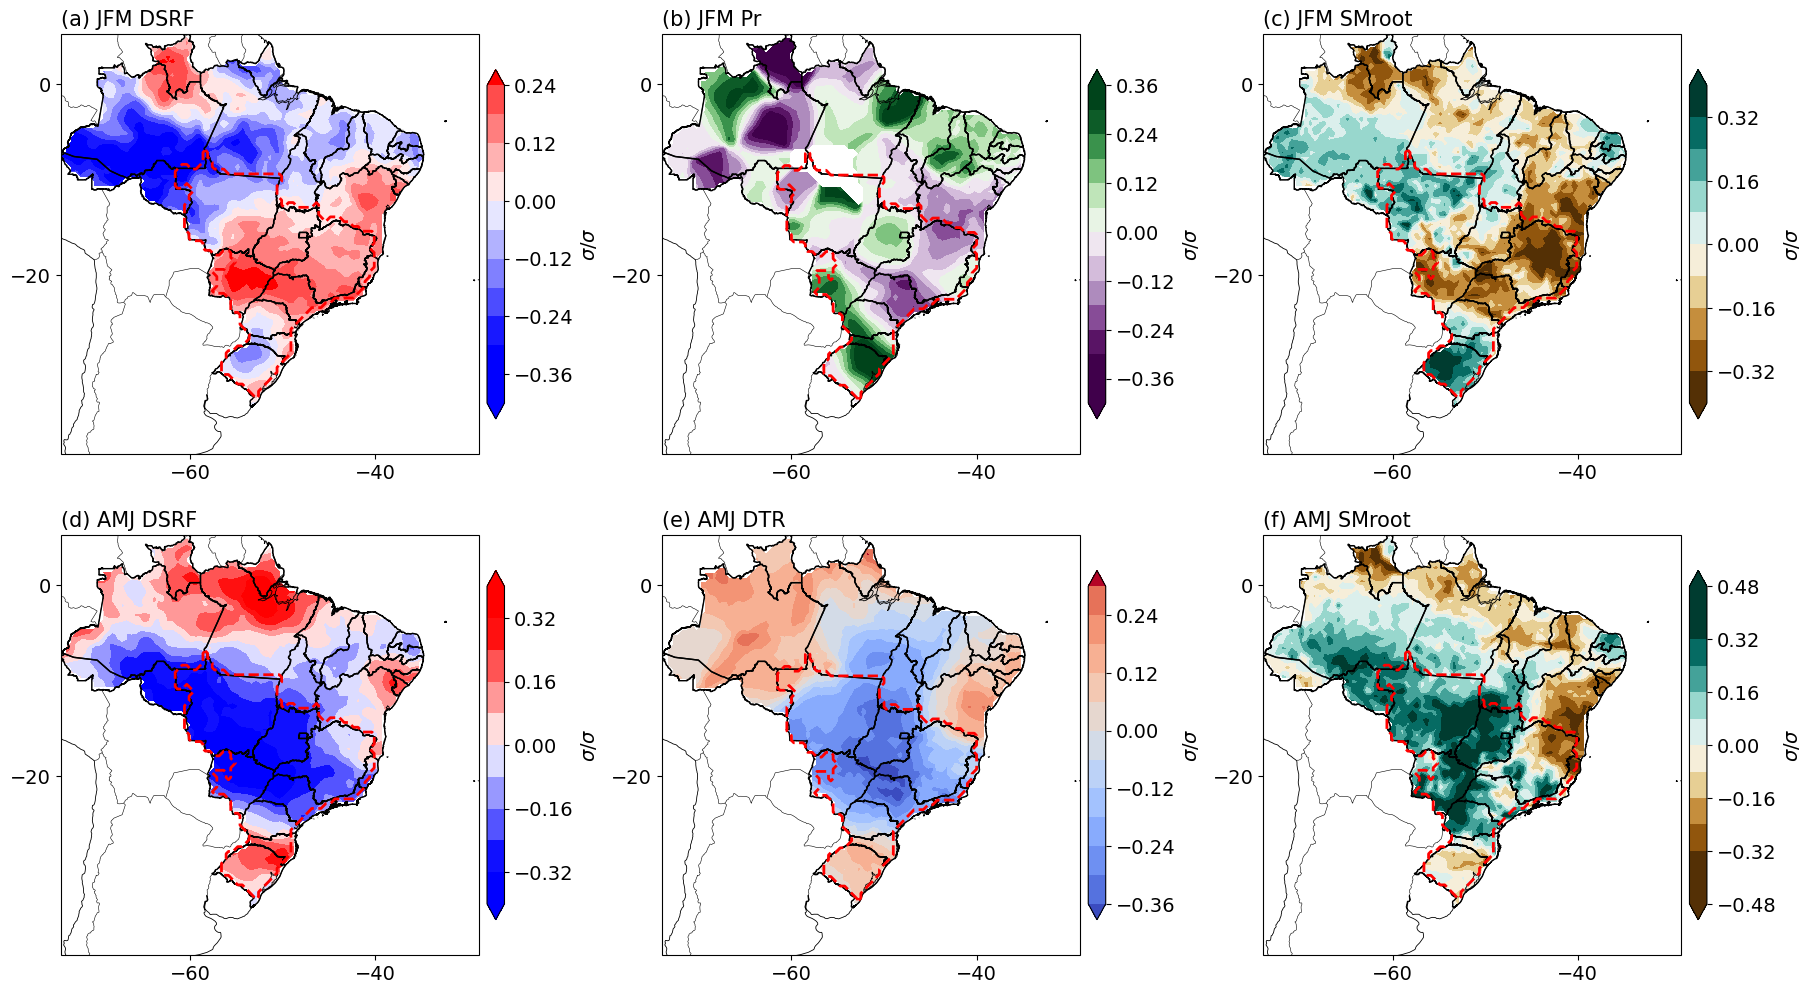

In [41]:
plot_2x3_panels(
    Brazil,
    data_dict,
    pv_thr=0.1,
    maize_bra=maize_bra,
    savepath='/Volumes/limenghan/巴西玉米/论文图/Figure4_AD_NDJ_weather_2x3.png'
)